# Retail Store Sales - Exploratory Data Analysis

## Objective

The objective of this project is to perform Exploratory Data Analysis
on retail store sales data to identify patterns, trends,
relationships, and important business insights.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Analysis Areas

1. Dataset Overview
2. Statistical Analysis
3. Category Analysis
4. Sales Analysis
5. Payment Method Analysis
6. Location Analysis
7. Time Series Analysis
8. Correlation Analysis
9. Key Insights

# Import Libraries

In [1]:
# Import Pandas for data manipulation
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import Seaborn for advanced visualizations
import seaborn as sns

# Set the visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Cleaned Dataset

In [3]:
# Load the cleaned retail sales dataset

df = pd.read_csv(
    "../data/cleaned/retail_store_sales_cleaned.csv"
)


In [4]:
# Display the first five rows
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,False
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


# Dataset Overview

In [5]:
# Display the number of rows and columns

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 12575
Columns: 11


In [6]:
# Display all column names

print("Dataset Columns:")
print(df.columns.tolist())

Dataset Columns:
['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit', 'Quantity', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date', 'Discount Applied']


In [7]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  12575 non-null  bool   
dtypes: bool(1), float64(3), object(7)
memory usage: 994.8+ KB


# Missing Values

In [8]:
# Check missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


In [13]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Display missing values
print("Missing Values:")
print(missing_values)

# Check whether any missing values exist
if missing_values[missing_values > 0].empty:
    print("\nNo missing values found in the dataset.")
else:
    # Create bar chart only if missing values exist
    plt.figure(figsize=(10, 5))

    missing_values[missing_values > 0].plot(kind="bar")

    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Save the visualization
    plt.savefig("../visualizations/eda_missing_values.png")
    plt.show()

Missing Values:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

No missing values found in the dataset.


# Statistical Summary

In [14]:
# Generate statistical summary for numerical columns

df.describe()

,Price Per Unit,Quantity,Total Spent
count,12575.000000,12575.000000,12575.000000
mean,23.348191,5.558648,130.208111
std,10.480413,2.790160,93.580667
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,52.000000
50%,23.000000,6.000000,110.000000
75%,32.000000,8.000000,192.000000
max,41.000000,10.000000,410.000000


# Category Analysis

In [15]:
# Count the number of transactions for each category

category_count = df["Category"].value_counts()

print(category_count)

Category
Electric household essentials         1591
Furniture                             1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    1558
Patisserie                            1528
Name: count, dtype: int64


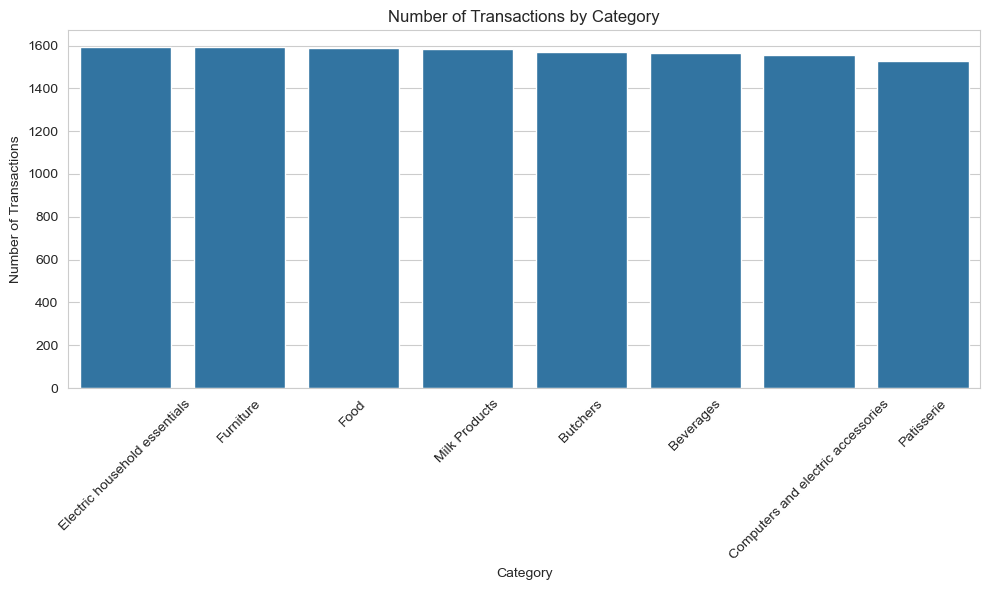

In [16]:
# Visualize the number of transactions by category

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.title("Number of Transactions by Category")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/eda_category_transactions.png")

plt.show()

# Sales by Category

In [17]:
# Calculate total sales for each category

category_sales = (
    df.groupby("Category")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Butchers                              218153.0
Electric household essentials         215297.5
Beverages                             206854.5
Furniture                             205390.0
Food                                  205225.0
Computers and electric accessories    202023.5
Patisserie                            194531.5
Milk Products                         189892.0
Name: Total Spent, dtype: float64


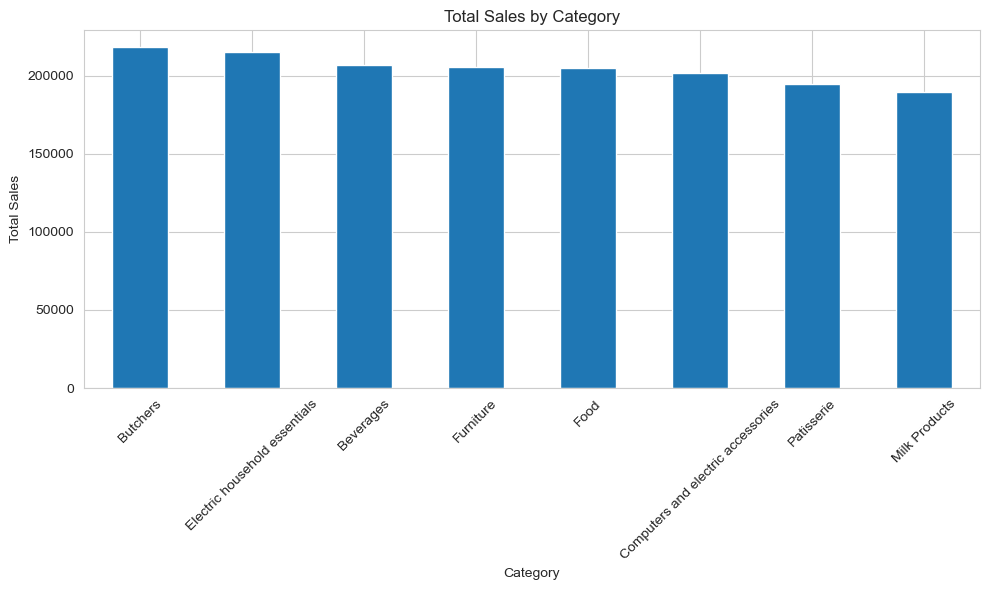

In [18]:
# Create a bar chart for total sales by category

plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/eda_sales_by_category.png")

plt.show()

# Payment Method Analysis

In [19]:
# Count transactions by payment method

payment_counts = df["Payment Method"].value_counts()

print(payment_counts)

Payment Method
Cash              4310
Digital Wallet    4144
Credit Card       4121
Name: count, dtype: int64


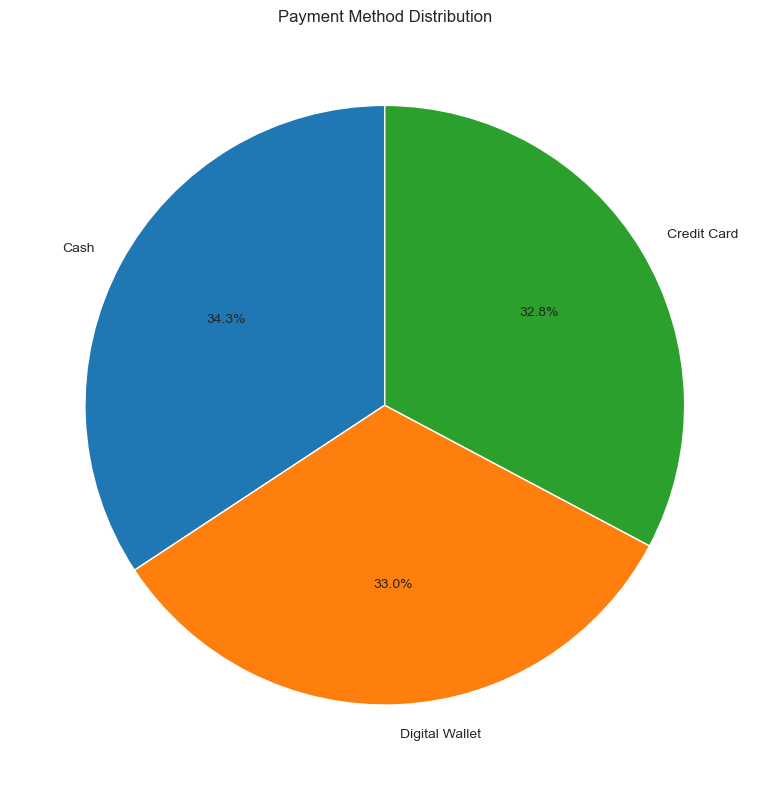

In [20]:
# Create a pie chart showing payment method distribution

plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Method Distribution")

plt.tight_layout()

plt.savefig("../visualizations/eda_payment_distribution.png")

plt.show()

# Location Analysis

In [21]:
# Count transactions by location

location_counts = df["Location"].value_counts()

print(location_counts)

Location
Online      6354
In-store    6221
Name: count, dtype: int64


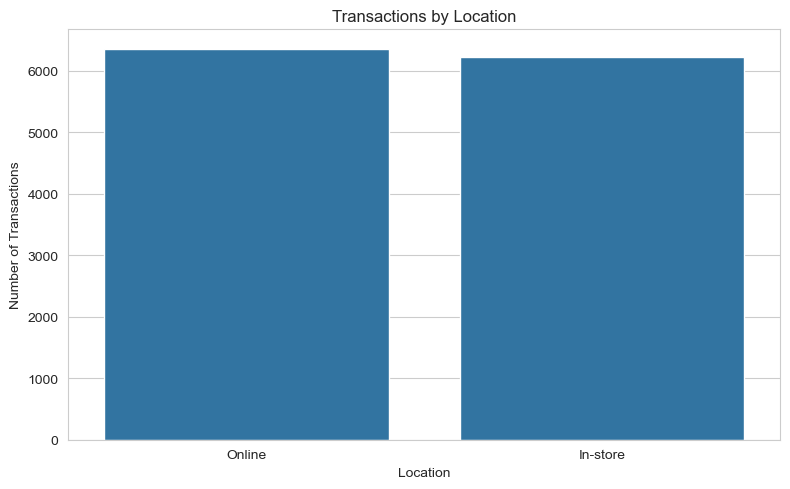

In [22]:
# Visualize transactions by location

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Location",
    order=location_counts.index
)

plt.title("Transactions by Location")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../visualizations/eda_location_analysis.png")

plt.show()

# Quantity Distribution

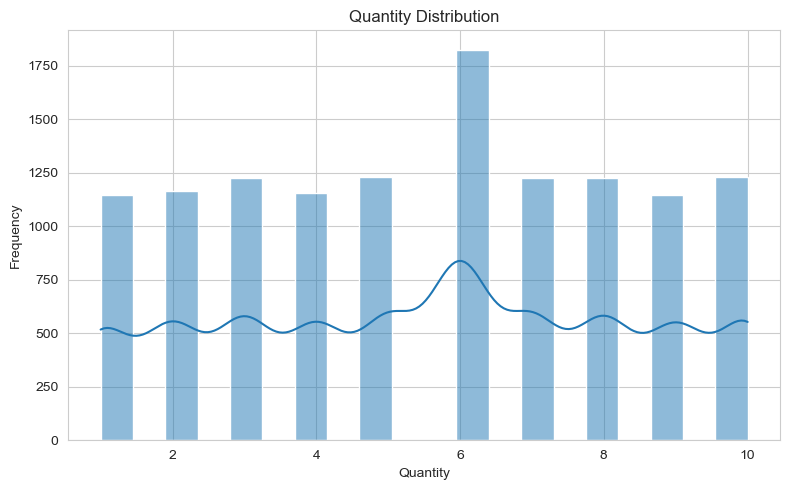

In [23]:
# Analyze the distribution of purchased quantities

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Quantity",
    bins=20,
    kde=True
)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../visualizations/eda_quantity_distribution.png")

plt.show()

# Total Spent Distribution

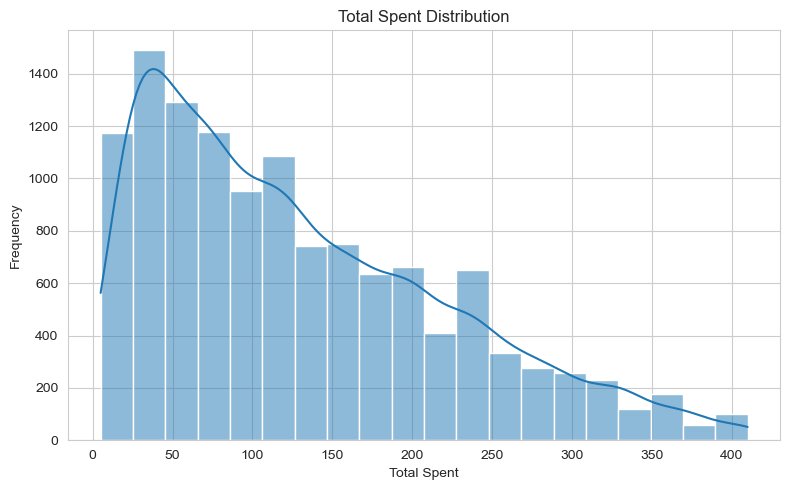

In [24]:
# Analyze the distribution of total spending

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Total Spent",
    bins=20,
    kde=True
)

plt.title("Total Spent Distribution")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../visualizations/eda_total_spent_distribution.png")

plt.show()

# Price vs Quantity

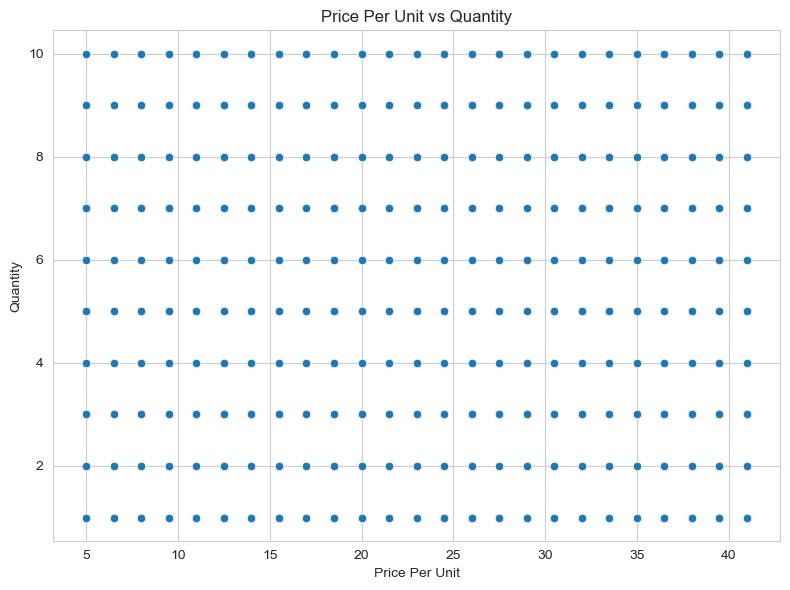

In [25]:
# Analyze the relationship between price and quantity

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Price Per Unit",
    y="Quantity"
)

plt.title("Price Per Unit vs Quantity")
plt.xlabel("Price Per Unit")
plt.ylabel("Quantity")

plt.tight_layout()

plt.savefig("../visualizations/eda_price_quantity.png")

plt.show()

# Correlation Analysis

In [26]:
# Select numerical columns for correlation analysis

numeric_columns = [
    "Price Per Unit",
    "Quantity",
    "Total Spent"
]

# Calculate the correlation matrix

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)

                Price Per Unit  Quantity  Total Spent
Price Per Unit        1.000000  0.011306     0.625595
Quantity              0.011306  1.000000     0.703938
Total Spent           0.625595  0.703938     1.000000


# Heatmap

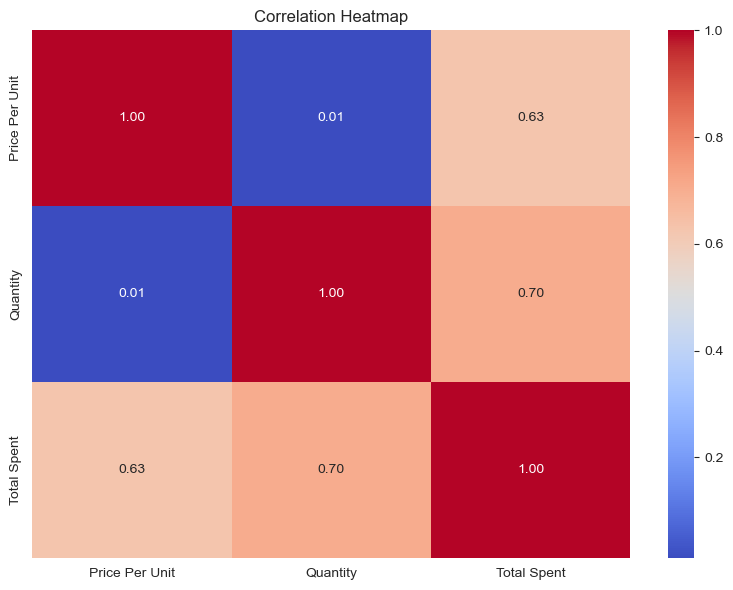

In [27]:
# Create a correlation heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../visualizations/eda_correlation_heatmap.png")

plt.show()

# Monthly Sales Analysis

In [28]:
# Convert Transaction Date into datetime format

df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"]
)

# Extract month from transaction date

df["Month"] = df["Transaction Date"].dt.month

In [29]:
# Calculate total sales for each month

monthly_sales = (
    df.groupby("Month")["Total Spent"]
    .sum()
)

print(monthly_sales)

Month
1     183637.0
2     127662.0
3     129844.0
4     132164.5
5     132076.5
6     135906.0
7     138364.0
8     129656.5
9     134522.0
10    125827.5
11    130101.5
12    137605.5
Name: Total Spent, dtype: float64


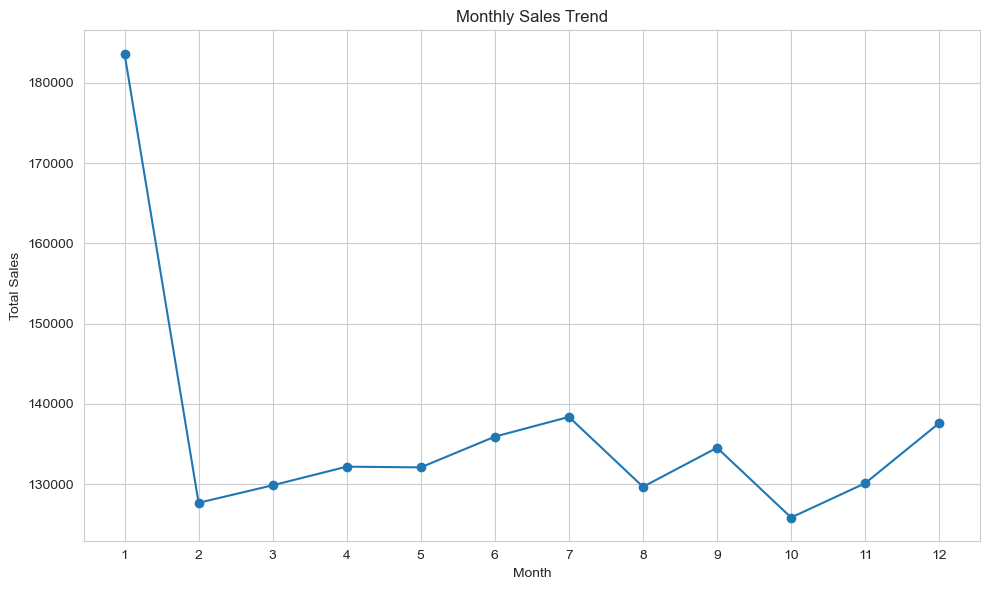

In [30]:
# Plot monthly sales trend

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(range(1, 13))

plt.tight_layout()

plt.savefig("../visualizations/eda_monthly_sales.png")

plt.show()

# Average Spending by Category

In [31]:
# Calculate average spending for each category

average_category_spending = (
    df.groupby("Category")["Total Spent"]
    .mean()
    .sort_values(ascending=False)
)

print(average_category_spending)

Category
Butchers                              139.128189
Electric household essentials         135.322124
Beverages                             132.006701
Computers and electric accessories    129.668485
Food                                  129.234887
Furniture                             129.094909
Patisserie                            127.311191
Milk Products                         119.881313
Name: Total Spent, dtype: float64


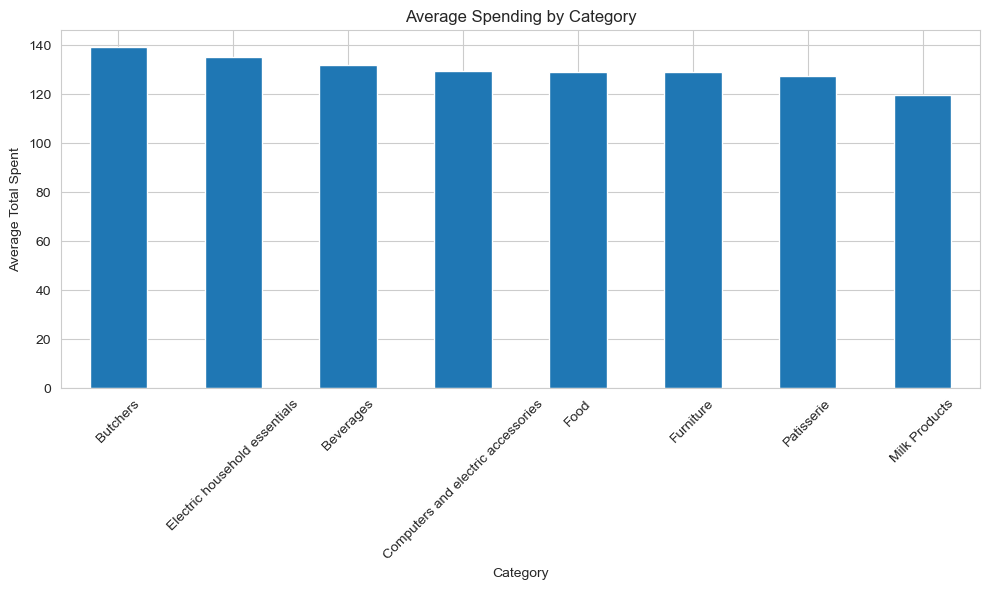

In [32]:
# Visualize average spending by category

plt.figure(figsize=(10, 6))

average_category_spending.plot(kind="bar")

plt.title("Average Spending by Category")
plt.xlabel("Category")
plt.ylabel("Average Total Spent")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/eda_average_spending_category.png")

plt.show()

# Discount Analysis

In [33]:
# Count transactions with and without discounts

discount_counts = df["Discount Applied"].value_counts()

print(discount_counts)

Discount Applied
False    8356
True     4219
Name: count, dtype: int64


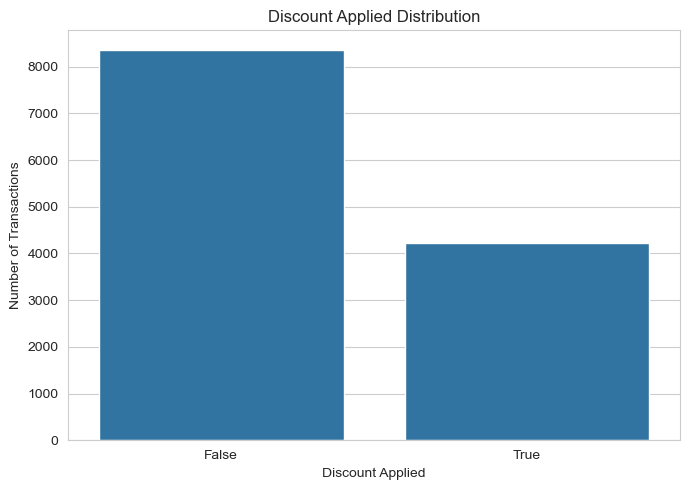

In [34]:
# Visualize discount usage

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Discount Applied"
)

plt.title("Discount Applied Distribution")
plt.xlabel("Discount Applied")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../visualizations/eda_discount_analysis.png")

plt.show()

# Category vs Total Spent

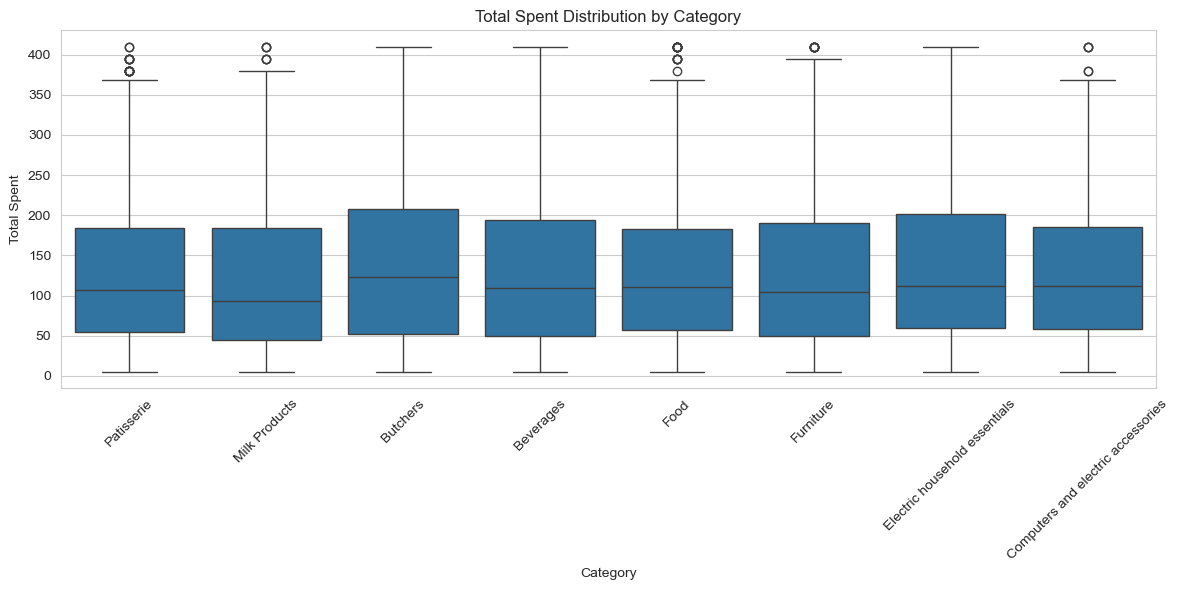

In [35]:
# Compare total spending across different categories

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="Category",
    y="Total Spent"
)

plt.title("Total Spent Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Total Spent")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../visualizations/eda_category_boxplot.png")

plt.show()

# Top 10 Products

In [36]:
# Find the top 10 products based on total sales

top_products = (
    df.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

Item
Unknown         164368.5
Item_25_FUR      25256.0
Item_25_EHE      23083.0
Item_25_BUT      21894.0
Item_24_FUR      21172.0
Item_25_FOOD     20541.0
Item_22_BUT      19710.0
Item_23_BUT      19114.0
Item_20_BUT      18860.5
Item_19_MILK     18848.0
Name: Total Spent, dtype: float64


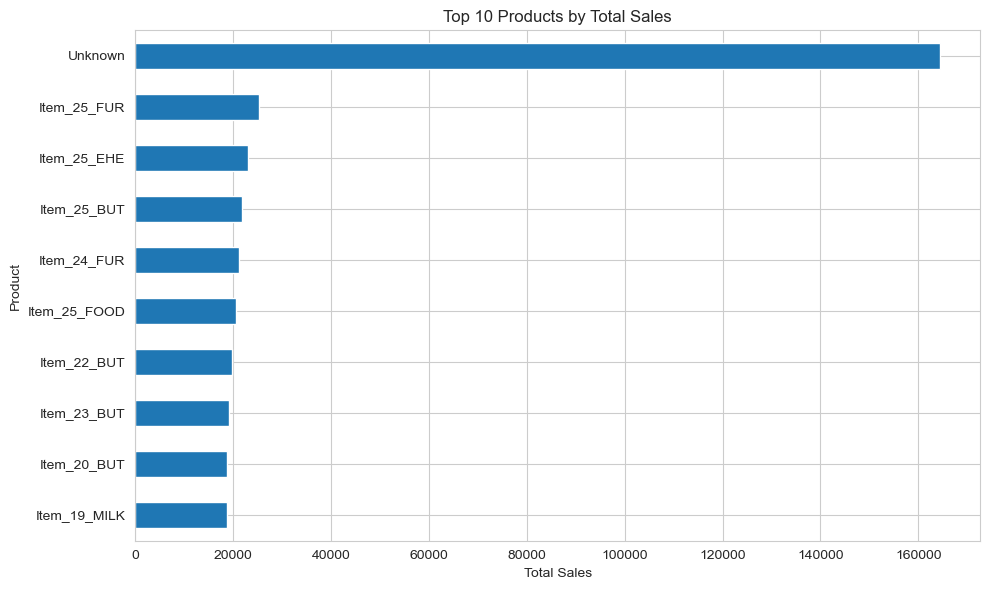

In [37]:
# Visualize the top 10 products by sales

plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig("../visualizations/eda_top_10_products.png")

plt.show()

# Generate Summary Statistics Table

In [38]:
# Create a summary table containing important metrics

summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Sales",
        "Average Sales",
        "Average Quantity",
        "Average Price"
    ],
    
    "Value": [
        len(df),
        df["Total Spent"].sum(),
        df["Total Spent"].mean(),
        df["Quantity"].mean(),
        df["Price Per Unit"].mean()
    ]
})

summary

,Metric,Value
0,Total Transactions,1.257500e+04
1,Total Sales,1.637367e+06
2,Average Sales,1.302081e+02
3,Average Quantity,5.558648e+00
4,Average Price,2.334819e+01


# Save Summary

In [39]:
# Save the EDA summary table

summary.to_csv(
    "../data/cleaned/eda_summary.csv",
    index=False
)

print("EDA summary saved successfully!")

EDA summary saved successfully!


# Final Insights

# Key Insights

## Dataset

- The dataset contains retail transaction-level information.
- Important variables include category, item, price, quantity,
  payment method, location, and total spending.

## Sales

- Total sales were analyzed across different product categories.
- Average spending was calculated to compare customer spending
  patterns across categories.

## Customer Purchasing Behavior

- Quantity distribution was analyzed to understand purchasing volume.
- Total spending distribution was analyzed to identify common
  spending ranges and potential extreme values.

## Payment Methods

- Different payment methods were compared based on transaction count.
- This helps understand customer payment preferences in the dataset.

## Location

- Transaction volumes were compared across available locations.
- This provides an overview of transaction activity by location.

## Time Trends

- Monthly sales were analyzed to identify changes in sales volume
  over time.

## Correlation

- Correlation analysis was performed between numerical variables
  such as Price Per Unit, Quantity, and Total Spent.
- Correlation indicates the strength and direction of a linear
  relationship and should not be interpreted as causation.

## Overall Conclusion

The EDA process helped identify patterns, distributions,
relationships, and trends in the retail sales dataset.
The visualizations and statistical analysis provide a structured
understanding of the dataset and can be used as a foundation for
further predictive modeling and business analysis.